# LAPS Experiment 1 — performance versus acceleration

This notebook compares our **patient-specific magnitude–phase residual INR** with the complex **LAPS-NeRP release implementation** on the SLAM test set.

The notebook supports both paper sampling arms. Choose `ACCELERATION_MODE = '1D'` or `'2D'` in the run-profile cell. Each arm has two acceleration views:

- 1D full curve $R \in \{3,5,6,7,9\}$; Table 2a subset $R \in \{3,6,9\}$;
- 2D full curve $R \in \{5,10,15,20,30\}$; Table 2b subset $R \in \{10,20,30\}$.

Every method receives the same retrospectively undersampled k-space and the same mask. The follow-up reference is used only after reconstruction for metrics and plots; it is never passed to either optimizer.

This is a **paper-like reproduction**, not a claim of exact reproduction of the published numbers. The default path uses the supplied SLAM sensitivity maps for practicality; the paper estimated maps from retained ACS data. The full paper cohorts are 225 slices per 1D acceleration (15 volumes × 15 slices) and 150 slices per 2D acceleration (10 volumes × 15 slices).

Provenance: [LAPS paper (arXiv:2407.00537)](https://arxiv.org/abs/2407.00537); baseline port audited against the local `/home/omarg/LAPS` checkout at commit `ca1b5cc8d0d24b164a848c6fbd06b3fc5ec7d99b`.

## What is being compared

Our primary model separates longitudinal magnitude change from follow-up phase:

$$
\hat m(c)=\max(f_{\mathrm{prior}}(c)+\Delta m(c),0),\qquad
\hat x(c)=\hat m(c)e^{i\phi(c)}.
$$

The prior INR is fitted once to the registered prior magnitude and frozen. For each acceleration, $\Delta m$ and $\phi$ are fitted from the measured follow-up k-space.

LAPS-NeRP first obtains phase from an acceleration-specific CG-SENSE reconstruction, constructs

$$p_{\mathrm{complex}}=|p_{\mathrm{DICOM}}|e^{i\angle x_{\mathrm{CG}}},$$

fits a two-output Fourier-feature SIREN to that complex prior, and then fine-tunes all weights through the k-space forward model. The released LAPS code trains with a real/imaginary $2\times2$ scale matrix but omits it from its final returned image. The notebook therefore reports both **LAPS-NeRP (released)** and the clearly labeled **+scale output** diagnostic from the same fit.

In [23]:
from __future__ import annotations

import copy
import gc
import hashlib
import math
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torchmetrics.functional.image import (
    peak_signal_noise_ratio,
    structural_similarity_index_measure,
)

REPO = Path.cwd().resolve()
if not (REPO / 'src' / 'presinr').exists():
    REPO = Path('/home/omarg/Patient-Specific-Residual-INR')
if not (REPO / 'src' / 'presinr').exists():
    raise RuntimeError('Open this notebook from the Patient-Specific-Residual-INR checkout.')
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

from presinr.baselines.laps_nerp import (
    CenterPaddedSense,
    LapsNerpConfig,
    LapsNerpStageConfig,
    conjugate_gradient_sense,
    fit_laps_nerp,
)
from presinr.data.slam import SlamTestSlices
from presinr.metrics import all_metrics
from presinr.models import PriorMagnitudePhaseINR, PriorResidualINR, build_inr
from presinr.recon import (
    KspaceFitConfig,
    MagnitudePhaseFitConfig,
    PhaseFitConfig,
    PriorFitConfig,
    ResidualFitConfig,
    fit_current_only,
    fit_magnitude_phase_residual,
    fit_phase_inr,
    fit_prior,
    fit_residual,
)
from presinr.sampling import (
    laps_retrospective_1d_mask,
    laps_retrospective_2d_mask,
)
from presinr.utils import center_pad_to, get_device, set_seed, to_numpy

DEVICE = get_device()
print('repository :', REPO)
print('python     :', sys.executable)
print('torch      :', torch.__version__)
print('device     :', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU        :', torch.cuda.get_device_name(DEVICE))

repository : /home/omarg/Patient-Specific-Residual-INR
python     : /home/omarg/miniforge3/envs/presinr-notebook/bin/python
torch      : 2.5.1+cu121
device     : cuda
GPU        : NVIDIA GeForce RTX 2080 Ti


## Run profile

`quick` validates the entire pipeline on one slice and the three table accelerations with shortened optimization. Its images and numbers are **not scientific results**.

`pilot` uses the exact optimization settings on one slice and the full five-point curve. `paper` selects 15 evenly spaced slices from every eligible volume (15 volumes for 1D; 10 for 2D) and uses the full curve. Exact LAPS-NeRP is expensive: its 1.84-million-parameter network is optimized once on the complex prior and once on k-space for every slice and acceleration.

Results are checkpointed to CSV after every method, so an interrupted long run can resume.

In [24]:
PROFILE = 'quick'  # 'quick', 'pilot', or 'paper'
ACCELERATION_MODE = '2D'  # '1D' Cartesian lines or '2D' point sampling
RESUME = True
VERBOSE_TRAINING = False

RUN_CURRENT_ONLY = PROFILE != 'paper'  # prior-free attribution; disable for huge paper run
RUN_COMPLEX_RESIDUAL = False   # older project formulation; primary method is magnitude-phase
REPORT_NERP_SCALE_OUTPUT = True

FULL_CURVES = {
    '1D': (3, 5, 6, 7, 9),
    '2D': (5, 10, 15, 20, 30),
}
TABLE_ACCELERATIONS = {
    '1D': (3, 6, 9),
    '2D': (10, 20, 30),
}
if ACCELERATION_MODE not in FULL_CURVES:
    raise ValueError("ACCELERATION_MODE must be '1D' or '2D'")
FULL_CURVE_R = FULL_CURVES[ACCELERATION_MODE]
TABLE_R = TABLE_ACCELERATIONS[ACCELERATION_MODE]
BASE_SEED = 42

if PROFILE == 'quick':
    ACCELERATIONS = TABLE_R
    SLICES_PER_VOLUME = 1
    MAX_CASES = 1
    OUR_PRIOR_CFG = PriorFitConfig(iters=200, lr=1e-4, log_every=50)
    OUR_PHASE_CFG = PhaseFitConfig(iters=100, lr=1e-4, log_every=50)
    OUR_MAG_PHASE_CFG = MagnitudePhaseFitConfig(
        iters=200,
        lr=1e-3,
        phase_lr=3e-4,
        lambda_change=1e-3,
        lambda_change_tv=0.0,
        lambda_phase_tv=1e-5,
        log_every=50,
    )
    OUR_COMPLEX_CFG = ResidualFitConfig(
        iters=200, lr=1e-3, lambda_res=1e-3, log_every=50
    )
    CURRENT_CFG = KspaceFitConfig(iters=200, lr=1e-3, log_every=50)
    NERP_CFG = LapsNerpConfig(
        # Architecture and CG remain release-exact; only optimizer lengths are shortened.
        prior_stage=LapsNerpStageConfig(
            max_iter=25, lr=1e-4, weight_decay=1e-4,
            min_iterations=24, patience=50,
        ),
        kspace_stage=LapsNerpStageConfig(
            max_iter=25, lr=1e-5, weight_decay=0.0,
            min_iterations=24, patience=100,
        ),
    )
elif PROFILE in {'pilot', 'paper'}:
    ACCELERATIONS = FULL_CURVE_R
    SLICES_PER_VOLUME = 1 if PROFILE == 'pilot' else 15
    MAX_CASES = 1 if PROFILE == 'pilot' else None
    OUR_PRIOR_CFG = PriorFitConfig(iters=3000, lr=1e-4, log_every=250)
    OUR_PHASE_CFG = PhaseFitConfig(iters=1000, lr=1e-4, log_every=250)
    OUR_MAG_PHASE_CFG = MagnitudePhaseFitConfig(
        iters=3000,
        lr=1e-3,
        phase_lr=3e-4,
        lambda_change=1e-3,
        lambda_change_tv=0.0,
        lambda_phase_tv=1e-5,
        log_every=250,
    )
    OUR_COMPLEX_CFG = ResidualFitConfig(
        iters=3000, lr=1e-3, lambda_res=1e-3, log_every=250
    )
    CURRENT_CFG = KspaceFitConfig(iters=3000, lr=1e-3, log_every=250)
    NERP_CFG = LapsNerpConfig()  # exact release optimization defaults
else:
    raise ValueError(f'Unknown PROFILE={PROFILE!r}')

RESULTS_DIR = REPO / 'reports' / 'laps_experiment1'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / f"results_{ACCELERATION_MODE.lower()}_{PROFILE}.csv"

print('profile       :', PROFILE)
print('sampling mode :', ACCELERATION_MODE)
print('accelerations :', ACCELERATIONS)
print('results       :', RESULTS_CSV)
if PROFILE == 'quick':
    warnings.warn('quick uses only 25+25 NeRP iterations; do not interpret its metrics as final.')

# The released LAPS reconstructor owns one fixed Fourier encoder and
# reuses it for all same-shaped reconstructions in a run.
nerp_fourier_generator = torch.Generator(device='cpu').manual_seed(BASE_SEED)
NERP_FOURIER_MATRIX = (
    torch.randn(
        NERP_CFG.embedding_size,
        NERP_CFG.coordinate_size,
        generator=nerp_fourier_generator,
    )
    * NERP_CFG.embedding_scale
)

profile       : quick
sampling mode : 2D
accelerations : (10, 20, 30)
results       : /home/omarg/Patient-Specific-Residual-INR/reports/laps_experiment1/results_2d_quick.csv


/tmp/ipykernel_92730/3813064986.py:86: UserWarning: quick uses only 25+25 NeRP iterations; do not interpret its metrics as final.
  warnings.warn('quick uses only 25+25 NeRP iterations; do not interpret its metrics as final.')


## Dataset preflight and paper cohort

The 1D arm includes scans with original `AccelNumDim` in `{0, 1}` (15 volumes). The 2D arm uses `{0, 2}` (10 volumes). The `paper` profile refuses to continue if the prepared per-slice manifest is incomplete.

In [25]:
dataset = SlamTestSlices(data_dir=REPO / 'data', middle_only=False, normalize=False)
manifest = dataset.df.copy().reset_index(drop=True)
manifest['dataset_position'] = np.arange(len(manifest))

required_columns = {
    'scan_index', 'slice_index', 'change_extent', 'AccelNumDim', 'index'
}
missing = required_columns - set(manifest.columns)
if missing:
    raise RuntimeError(f'Prepared manifest is missing columns: {sorted(missing)}')

eligible_dimensions = {'1D': [0, 1], '2D': [0, 2]}[ACCELERATION_MODE]
expected_volumes = {'1D': 15, '2D': 10}[ACCELERATION_MODE]
expected_paper_cases = expected_volumes * 15
eligible = manifest[manifest['AccelNumDim'].isin(eligible_dimensions)].copy()

def evenly_spaced_cases(frame, slices_per_volume):
    chosen = []
    for _, group in frame.groupby('scan_index', sort=True):
        group = group.sort_values('slice_index')
        n_take = min(slices_per_volume, len(group))
        if n_take == 1:
            locations = np.asarray([len(group) // 2])
        else:
            locations = np.linspace(0, len(group) - 1, n_take, dtype=int)
        chosen.append(group.iloc[np.unique(locations)])
    return pd.concat(chosen, ignore_index=True) if chosen else frame.iloc[:0]

selected_cases = evenly_spaced_cases(eligible, SLICES_PER_VOLUME)
if MAX_CASES is not None:
    selected_cases = selected_cases.iloc[:MAX_CASES].copy()

n_prepared_scans = manifest['scan_index'].nunique()
n_eligible_scans = eligible['scan_index'].nunique()
print(f'prepared slices/volumes : {len(manifest)} / {n_prepared_scans}')
print(
    f'eligible {ACCELERATION_MODE} volumes     : '
    f'{n_eligible_scans} (paper expects {expected_volumes})'
)
print(f'selected cases          : {len(selected_cases)}')

if n_prepared_scans < 21:
    print('\nThe raw archives may be present, but the prepared CSV is incomplete.')
    print('Finish preprocessing from a terminal with:')
    print(
        "  conda run -n presinr-notebook python -c "
        "\"from pathlib import Path; from presinr.data.slam import prepare_test; "
        "prepare_test(Path('data'))\""
    )

if PROFILE == 'paper' and (
    n_eligible_scans != expected_volumes
    or len(selected_cases) != expected_paper_cases
):
    raise RuntimeError(
        f'paper {ACCELERATION_MODE} profile requires {expected_volumes} '
        f'eligible volumes and {expected_paper_cases} selected slices. '
        'Complete SLAM per-slice preparation first.'
    )

display(
    selected_cases[
        ['dataset_position', 'scan_index', 'slice_index', 'change_extent', 'AccelNumDim']
    ].head(20)
)

prepared slices/volumes : 1958 / 21
eligible 2D volumes     : 10 (paper expects 10)
selected cases          : 1


,dataset_position,scan_index,slice_index,change_extent,AccelNumDim
0,53,0,53,1,2


## Shared masks, geometry, normalization, and metrics

For each case and $R$:

1. the LAPS variable-density rule selects only lines/points that were actually acquired;
2. the same mask and k-space tensor are reused by every method;
3. k-space is rescaled by $Q_{0.999}(|A_R^H y_R|)$, independently for every $R$;
4. all INRs predict the stored grid (usually $256\times256$), while the forward model center-crops to the native k-space grid;
5. every output is multiplied by the same sensitivity support before evaluation.

Two metric families are kept separate:

- `laps_psnr` / `laps_ssim`: target divided by its 99th percentile, then each reconstruction gets a least-squares scalar alignment to the target. These are comparable in definition to the paper.
- `psnr` / `ssim` / `nmse`, change metrics, MI, and magnitude MAE/RMSE: the project-native, non-oracle evaluation. These expose amplitude errors that LAPS-style scalar alignment can hide.

In [26]:
def stable_seed(*parts, base=BASE_SEED):
    payload = '|'.join(map(str, (base,) + parts)).encode('utf-8')
    return int(hashlib.sha256(payload).hexdigest()[:8], 16) % (2**31 - 1)


def quantile_scale(tensor, q=0.999):
    values = tensor.detach().abs().reshape(-1).float()
    return float(torch.quantile(values, q)) + 1e-8


def normalized_reference_and_prior(sample):
    reference = sample['recon'].to(torch.complex64)
    prior = sample['prior'].float()
    reference = reference / quantile_scale(reference, 0.999)
    prior = prior / quantile_scale(prior, 0.999)
    return reference, prior


def prepare_measurements(sample, requested_r, mask_seed):
    input_mask = sample['mask'].float()
    if ACCELERATION_MODE == '1D':
        mask, mask_info = laps_retrospective_1d_mask(
            input_mask,
            requested_r,
            seed=mask_seed,
            vd_factor=0.8,
            n_candidates=100,
        )
    else:
        mask, mask_info = laps_retrospective_2d_mask(
            input_mask,
            requested_r,
            seed=mask_seed,
            vd_factor=1.5,
        )
    kspace = sample['ksp'].to(torch.complex64) * mask
    operator = CenterPaddedSense(
        sample['mps'].to(torch.complex64),
        mask,
        sample['stored_shape'],
    )
    scale = quantile_scale(operator.adjoint(kspace), 0.999)
    kspace = kspace / scale
    zero_filled = operator.adjoint(kspace)
    support_native = torch.linalg.vector_norm(sample['mps'], dim=0) > 0.5
    support = center_pad_to(support_native.float(), sample['stored_shape'])
    return operator, kspace, zero_filled, support, mask, mask_info, scale


def align_magnitude_laps(reconstruction, reference):
    target = np.abs(to_numpy(reference)).astype(np.float64)
    target = target / (np.quantile(target, 0.99) + 1e-12)
    estimate = np.abs(to_numpy(reconstruction)).astype(np.float64)
    denominator = float(np.sum(estimate * estimate))
    gain = 1.0 if denominator <= 1e-20 else float(np.sum(estimate * target) / denominator)
    return gain * estimate, target, gain


def laps_metrics(reconstruction, reference):
    estimate, target, gain = align_magnitude_laps(reconstruction, reference)
    estimate_tensor = torch.as_tensor(estimate, dtype=torch.float32)
    target_tensor = torch.as_tensor(target, dtype=torch.float32)
    return {
        'laps_psnr': float(
            peak_signal_noise_ratio(
                estimate_tensor[None],
                target_tensor[None],
                data_range=1.0,
                reduction='none',
                dim=(-2, -1),
            )
        ),
        'laps_ssim': float(
            structural_similarity_index_measure(
                estimate_tensor[None, None],
                target_tensor[None, None],
                data_range=1.0,
                reduction='none',
            )
        ),
        'laps_gain': gain,
    }


def magnitude_error_metrics(reconstruction, reference):
    estimate = np.abs(to_numpy(reconstruction)).astype(np.float64)
    target = np.abs(to_numpy(reference)).astype(np.float64)
    error = estimate - target
    rmse = float(np.sqrt(np.mean(error**2)))
    return {
        'magnitude_mae': float(np.mean(np.abs(error))),
        'magnitude_rmse': rmse,
        'magnitude_nrmse': float(
            np.linalg.norm(error) / (np.linalg.norm(target) + 1e-12)
        ),
        'magnitude_error_max': float(np.max(np.abs(error))),
    }


def relative_data_error(reconstruction, operator, kspace):
    with torch.no_grad():
        residual = operator(reconstruction.to(DEVICE)) - kspace.to(DEVICE)
        return float(
            torch.linalg.vector_norm(residual)
            / (torch.linalg.vector_norm(kspace.to(DEVICE)) + 1e-12)
        )


def metric_record(reconstruction, reference, prior, operator, kspace):
    output = all_metrics(reconstruction, reference, prior)
    output.update(laps_metrics(reconstruction, reference))
    output.update(magnitude_error_metrics(reconstruction, reference))
    output['relative_data_error'] = relative_data_error(
        reconstruction, operator, kspace
    )
    return output

## Inspect the actual retrospective masks

White pixels are retained k-space samples. The plotted zero-filled images use **only the selected samples**; the reference image does not enter this cell's reconstruction path.

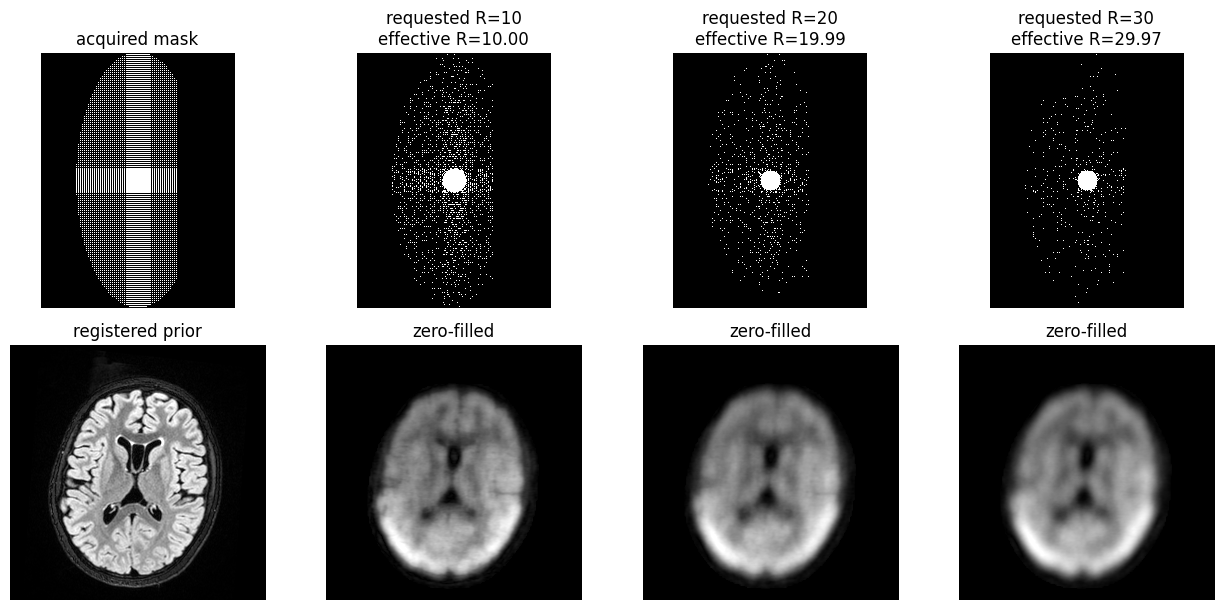

In [27]:
if len(selected_cases) == 0:
    raise RuntimeError('No eligible cases found.')

preview_row = selected_cases.iloc[0]
preview_sample = dataset[int(preview_row['dataset_position'])]
preview_reference, preview_prior = normalized_reference_and_prior(preview_sample)

figure, axes = plt.subplots(2, len(ACCELERATIONS) + 1, figsize=(3.2 * (len(ACCELERATIONS) + 1), 6.2))
axes[0, 0].imshow(to_numpy(preview_sample['mask']), cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('acquired mask')
axes[1, 0].imshow(np.abs(to_numpy(preview_prior)), cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('registered prior')

for column, requested_r in enumerate(ACCELERATIONS, start=1):
    mask_seed = stable_seed('mask', int(preview_row['index']), requested_r)
    operator, kspace, zf, support, mask, info, _ = prepare_measurements(
        preview_sample, requested_r, mask_seed
    )
    axes[0, column].imshow(to_numpy(mask), cmap='gray', vmin=0, vmax=1)
    axes[0, column].set_title(
        f'requested R={requested_r}\neffective R={info.effective_acceleration:.2f}'
    )
    axes[1, column].imshow(np.abs(to_numpy(zf * support)), cmap='gray', vmin=0, vmax=1)
    axes[1, column].set_title('zero-filled')

for axis in axes.flat:
    axis.axis('off')
figure.tight_layout()
plt.show()

## Reconstruction functions

The project prior fit is cached once per slice because its target is independent of $R$. LAPS-NeRP is deliberately re-fitted at every $R$: its pseudo-complex prior contains the phase of the $R$-specific CG reconstruction.

In [28]:
def make_prior_inr():
    return build_inr(
        'siren', out_features=1, hidden_features=256, hidden_layers=4
    )


def fit_shared_prior(prior, seed):
    set_seed(seed)
    network = make_prior_inr().to(DEVICE)
    started = time.perf_counter()
    history = fit_prior(
        network,
        prior.to(DEVICE),
        cfg=OUR_PRIOR_CFG,
        device=DEVICE,
        verbose=VERBOSE_TRAINING,
    )
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    state = {
        key: value.detach().cpu().clone()
        for key, value in network.state_dict().items()
    }
    del network
    return state, history, elapsed


def run_ours_magnitude_phase(prior_state, operator, kspace, shape, seed):
    set_seed(seed)
    prior_network = make_prior_inr().to(DEVICE)
    prior_network.load_state_dict(prior_state)
    magnitude_change = build_inr(
        'siren', out_features=1, hidden_features=128, hidden_layers=4
    ).to(DEVICE)
    phase_network = build_inr(
        'siren', out_features=1, hidden_features=64, hidden_layers=3
    ).to(DEVICE)

    zero_filled = operator.to(DEVICE).adjoint(kspace.to(DEVICE))
    phase_weights = (
        zero_filled.abs() / quantile_scale(zero_filled, 0.99)
    ).clamp(0.0, 1.0)
    started = time.perf_counter()
    phase_history = fit_phase_inr(
        phase_network,
        torch.angle(zero_filled),
        cfg=OUR_PHASE_CFG,
        weights=phase_weights,
        device=DEVICE,
        verbose=VERBOSE_TRAINING,
    )
    model = PriorMagnitudePhaseINR(
        prior_network, magnitude_change, phase_network
    )
    result = fit_magnitude_phase_residual(
        model,
        operator,
        kspace,
        shape,
        cfg=OUR_MAG_PHASE_CFG,
        device=DEVICE,
        verbose=VERBOSE_TRAINING,
    )
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - started
    result.history['phase_initialization'] = phase_history
    return result, elapsed


def run_ours_complex_residual(prior_state, operator, kspace, shape, seed):
    set_seed(seed)
    prior_network = make_prior_inr().to(DEVICE)
    prior_network.load_state_dict(prior_state)
    residual_network = build_inr(
        'siren', out_features=2, hidden_features=256, hidden_layers=4
    ).to(DEVICE)
    model = PriorResidualINR(prior_network, residual_network)
    started = time.perf_counter()
    result = fit_residual(
        model,
        operator,
        kspace,
        shape,
        cfg=OUR_COMPLEX_CFG,
        device=DEVICE,
        verbose=VERBOSE_TRAINING,
    )
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    return result, time.perf_counter() - started


def run_current_only(operator, kspace, shape, seed):
    set_seed(seed)
    network = build_inr(
        'siren', out_features=2, hidden_features=256, hidden_layers=4
    ).to(DEVICE)
    started = time.perf_counter()
    result = fit_current_only(
        network,
        operator,
        kspace,
        shape,
        cfg=CURRENT_CFG,
        device=DEVICE,
        verbose=VERBOSE_TRAINING,
    )
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    return result, time.perf_counter() - started


def run_laps_nerp(prior, operator, kspace, seed):
    set_seed(seed)
    started = time.perf_counter()
    result = fit_laps_nerp(
        prior,
        operator,
        kspace,
        config=NERP_CFG,
        device=DEVICE,
        fourier_matrix=NERP_FOURIER_MATRIX,
        verbose=VERBOSE_TRAINING,
    )
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    return result, time.perf_counter() - started


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Run / resume the acceleration sweep

Runtime columns distinguish the shared prior fit from the $R$-specific fit. `amortized_runtime_seconds` adds one share of the cached prior-fit time to our per-$R$ runtime. LAPS-NeRP's runtime already includes both of its acceleration-specific stages.

In [29]:
if RESUME and RESULTS_CSV.exists():
    results = pd.read_csv(RESULTS_CSV)
    print(f'Resuming from {len(results)} rows in {RESULTS_CSV}')
else:
    results = pd.DataFrame()

artifacts = {}


def is_done(dataset_position, requested_r, method):
    if results.empty:
        return False
    required = {'dataset_position', 'requested_r', 'method'}
    if not required.issubset(results.columns):
        return False
    match = (
        (results['dataset_position'] == dataset_position)
        & (results['requested_r'] == requested_r)
        & (results['method'] == method)
    )
    return bool(match.any())


def save_result(
    *,
    reconstruction,
    method,
    case_row,
    requested_r,
    mask_seed,
    mask_info,
    operator,
    kspace,
    reference,
    prior,
    runtime_seconds,
    shared_prior_seconds=0.0,
    iteration_1=np.nan,
    iteration_2=np.nan,
):
    global results
    reconstruction = reconstruction.detach().cpu()
    metrics = metric_record(
        reconstruction,
        reference.cpu(),
        prior.cpu(),
        operator,
        kspace,
    )
    record = {
        'profile': PROFILE,
        'dataset_position': int(case_row['dataset_position']),
        'sample_index': int(case_row['index']),
        'scan_index': int(case_row['scan_index']),
        'slice_index': int(case_row['slice_index']),
        'change_extent': int(case_row['change_extent']),
        'original_accel_dims': int(case_row['AccelNumDim']),
        'sampling_mode': ACCELERATION_MODE,
        'requested_r': float(requested_r),
        'effective_r': float(mask_info.effective_acceleration),
        'phase_encode_dim': int(mask_info.phase_encode_dim),
        'input_samples': int(mask_info.input_lines),
        'sampled_samples': int(mask_info.output_lines),
        'center_samples': int(mask_info.center_lines),
        'mask_seed': int(mask_seed),
        'method': method,
        'runtime_seconds': float(runtime_seconds),
        'shared_prior_fit_seconds': float(shared_prior_seconds),
        'amortized_runtime_seconds': float(
            runtime_seconds + shared_prior_seconds / len(ACCELERATIONS)
        ),
        'stage1_iterations': iteration_1,
        'stage2_iterations': iteration_2,
        **metrics,
    }
    results = pd.concat([results, pd.DataFrame([record])], ignore_index=True)
    results.to_csv(RESULTS_CSV, index=False)
    print(
        f"saved {method:34s} sample={int(case_row['index']):4d} "
        f"R={requested_r:g}  LAPS-PSNR={metrics['laps_psnr']:.2f}"
    )


primary_method = 'Ours: magnitude-phase residual'
complex_method = 'Ours: complex residual'
current_method = 'Current-only complex INR'
prior_method = 'Registered prior'
nerp_release_method = 'LAPS-NeRP (released)'
nerp_scaled_method = 'LAPS-NeRP (+scale output)'

for case_number, (_, case_row) in enumerate(selected_cases.iterrows(), start=1):
    dataset_position = int(case_row['dataset_position'])
    sample = dataset[dataset_position]
    reference, prior = normalized_reference_and_prior(sample)
    shape = tuple(sample['stored_shape'])
    print(
        f"\nCase {case_number}/{len(selected_cases)}: "
        f"scan={int(case_row['scan_index'])}, slice={int(case_row['slice_index'])}"
    )

    ours_methods = [primary_method]
    if RUN_COMPLEX_RESIDUAL:
        ours_methods.append(complex_method)
    needs_prior = any(
        not is_done(dataset_position, requested_r, method)
        for requested_r in ACCELERATIONS
        for method in ours_methods
    )
    prior_state = prior_history = None
    shared_prior_seconds = 0.0
    if needs_prior:
        prior_state, prior_history, shared_prior_seconds = fit_shared_prior(
            prior,
            stable_seed('ours-prior', int(case_row['index'])),
        )

    for requested_r in ACCELERATIONS:
        mask_seed = stable_seed('mask', int(case_row['index']), requested_r)
        operator, kspace, zero_filled, support, mask, mask_info, kspace_scale = (
            prepare_measurements(sample, requested_r, mask_seed)
        )
        operator = operator.to(DEVICE)
        kspace = kspace.to(DEVICE)
        support = support.to(DEVICE)

        artifact = {
            'reference': reference.cpu(),
            'prior': prior.cpu(),
            'mask': mask.cpu(),
            'zero_filled': (zero_filled.to(DEVICE) * support).cpu(),
            'effective_r': mask_info.effective_acceleration,
            'recons': {},
            'histories': {},
        }

        if not is_done(dataset_position, requested_r, prior_method):
            prior_recon = prior.to(DEVICE) * support
            save_result(
                reconstruction=prior_recon,
                method=prior_method,
                case_row=case_row,
                requested_r=requested_r,
                mask_seed=mask_seed,
                mask_info=mask_info,
                operator=operator,
                kspace=kspace,
                reference=reference,
                prior=prior,
                runtime_seconds=0.0,
            )

        if not is_done(dataset_position, requested_r, 'Zero-filled'):
            zf_recon = zero_filled.to(DEVICE) * support
            save_result(
                reconstruction=zf_recon,
                method='Zero-filled',
                case_row=case_row,
                requested_r=requested_r,
                mask_seed=mask_seed,
                mask_info=mask_info,
                operator=operator,
                kspace=kspace,
                reference=reference,
                prior=prior,
                runtime_seconds=0.0,
            )
            artifact['recons']['Zero-filled'] = zf_recon.detach().cpu()

        if not is_done(dataset_position, requested_r, 'CG-SENSE'):
            started = time.perf_counter()
            cg_recon = conjugate_gradient_sense(
                operator,
                kspace,
                num_iters=15,
                lambda_l2=1e-4,
                tolerance=1e-10,
            )
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            cg_elapsed = time.perf_counter() - started
            cg_recon = cg_recon * support
            save_result(
                reconstruction=cg_recon,
                method='CG-SENSE',
                case_row=case_row,
                requested_r=requested_r,
                mask_seed=mask_seed,
                mask_info=mask_info,
                operator=operator,
                kspace=kspace,
                reference=reference,
                prior=prior,
                runtime_seconds=cg_elapsed,
                iteration_1=15,
            )
            artifact['recons']['CG-SENSE'] = cg_recon.detach().cpu()

        if not is_done(dataset_position, requested_r, primary_method):
            ours_result, ours_elapsed = run_ours_magnitude_phase(
                prior_state,
                operator,
                kspace,
                shape,
                stable_seed('ours-mag-phase', int(case_row['index']), requested_r),
            )
            ours_recon = ours_result.recon * support
            save_result(
                reconstruction=ours_recon,
                method=primary_method,
                case_row=case_row,
                requested_r=requested_r,
                mask_seed=mask_seed,
                mask_info=mask_info,
                operator=operator,
                kspace=kspace,
                reference=reference,
                prior=prior,
                runtime_seconds=ours_elapsed,
                shared_prior_seconds=shared_prior_seconds,
                iteration_1=len(ours_result.history['phase_initialization']['loss']),
                iteration_2=len(ours_result.history['loss']),
            )
            artifact['recons'][primary_method] = ours_recon.detach().cpu()
            artifact['histories'][primary_method] = ours_result.history
            del ours_result, ours_recon
            cleanup_cuda()

        if RUN_COMPLEX_RESIDUAL and not is_done(
            dataset_position, requested_r, complex_method
        ):
            complex_result, complex_elapsed = run_ours_complex_residual(
                prior_state,
                operator,
                kspace,
                shape,
                stable_seed('ours-complex', int(case_row['index']), requested_r),
            )
            complex_recon = complex_result.recon * support
            save_result(
                reconstruction=complex_recon,
                method=complex_method,
                case_row=case_row,
                requested_r=requested_r,
                mask_seed=mask_seed,
                mask_info=mask_info,
                operator=operator,
                kspace=kspace,
                reference=reference,
                prior=prior,
                runtime_seconds=complex_elapsed,
                shared_prior_seconds=shared_prior_seconds,
                iteration_2=len(complex_result.history['loss']),
            )
            artifact['recons'][complex_method] = complex_recon.detach().cpu()
            del complex_result, complex_recon
            cleanup_cuda()

        if RUN_CURRENT_ONLY and not is_done(
            dataset_position, requested_r, current_method
        ):
            current_result, current_elapsed = run_current_only(
                operator,
                kspace,
                shape,
                stable_seed('current-only', int(case_row['index']), requested_r),
            )
            current_recon = current_result.recon * support
            save_result(
                reconstruction=current_recon,
                method=current_method,
                case_row=case_row,
                requested_r=requested_r,
                mask_seed=mask_seed,
                mask_info=mask_info,
                operator=operator,
                kspace=kspace,
                reference=reference,
                prior=prior,
                runtime_seconds=current_elapsed,
                iteration_2=len(current_result.history['loss']),
            )
            artifact['recons'][current_method] = current_recon.detach().cpu()
            del current_result, current_recon
            cleanup_cuda()

        need_nerp = not is_done(dataset_position, requested_r, nerp_release_method)
        if REPORT_NERP_SCALE_OUTPUT:
            need_nerp = need_nerp or not is_done(
                dataset_position, requested_r, nerp_scaled_method
            )
        if need_nerp:
            nerp_result, nerp_elapsed = run_laps_nerp(
                prior,
                operator,
                kspace,
                stable_seed('laps-nerp', int(case_row['index']), requested_r),
            )
            nerp_released = nerp_result.recon_released * support
            if not is_done(dataset_position, requested_r, nerp_release_method):
                save_result(
                    reconstruction=nerp_released,
                    method=nerp_release_method,
                    case_row=case_row,
                    requested_r=requested_r,
                    mask_seed=mask_seed,
                    mask_info=mask_info,
                    operator=operator,
                    kspace=kspace,
                    reference=reference,
                    prior=prior,
                    runtime_seconds=nerp_elapsed,
                    iteration_1=len(nerp_result.prior_history['loss']),
                    iteration_2=len(nerp_result.kspace_history['loss']),
                )
            artifact['recons'][nerp_release_method] = nerp_released.detach().cpu()
            artifact['histories'][nerp_release_method] = {
                'prior': nerp_result.prior_history,
                'kspace': nerp_result.kspace_history,
            }

            if REPORT_NERP_SCALE_OUTPUT:
                nerp_scaled = nerp_result.recon_scaled * support
                if not is_done(dataset_position, requested_r, nerp_scaled_method):
                    save_result(
                        reconstruction=nerp_scaled,
                        method=nerp_scaled_method,
                        case_row=case_row,
                        requested_r=requested_r,
                        mask_seed=mask_seed,
                        mask_info=mask_info,
                        operator=operator,
                        kspace=kspace,
                        reference=reference,
                        prior=prior,
                        runtime_seconds=nerp_elapsed,
                        iteration_1=len(nerp_result.prior_history['loss']),
                        iteration_2=len(nerp_result.kspace_history['loss']),
                    )
                artifact['recons'][nerp_scaled_method] = nerp_scaled.detach().cpu()
            del nerp_result, nerp_released
            cleanup_cuda()

        # Keep only the first case's in-memory reconstructions for qualitative plots.
        if case_number == 1:
            artifacts[requested_r] = artifact

    del sample
    cleanup_cuda()

print(f'\nCompleted profile={PROFILE}; {len(results)} result rows saved to {RESULTS_CSV}')


Case 1/1: scan=0, slice=53
saved Registered prior                   sample=  53 R=10  LAPS-PSNR=18.96
saved Zero-filled                        sample=  53 R=10  LAPS-PSNR=23.33
saved CG-SENSE                           sample=  53 R=10  LAPS-PSNR=27.89
saved Ours: magnitude-phase residual     sample=  53 R=10  LAPS-PSNR=20.92
saved Current-only complex INR           sample=  53 R=10  LAPS-PSNR=19.84
saved LAPS-NeRP (released)               sample=  53 R=10  LAPS-PSNR=23.47
saved LAPS-NeRP (+scale output)          sample=  53 R=10  LAPS-PSNR=23.93
saved Registered prior                   sample=  53 R=20  LAPS-PSNR=18.96
saved Zero-filled                        sample=  53 R=20  LAPS-PSNR=22.35
saved CG-SENSE                           sample=  53 R=20  LAPS-PSNR=26.26
saved Ours: magnitude-phase residual     sample=  53 R=20  LAPS-PSNR=18.11
saved Current-only complex INR           sample=  53 R=20  LAPS-PSNR=18.05
saved LAPS-NeRP (released)               sample=  53 R=20  LAPS-PSNR=22.

## Aggregate performance versus acceleration

The primary table uses the LAPS metric definition and reports mean ± standard deviation, matching the paper's summary convention. With one quick/pilot case, the standard deviation is undefined and shown as `nan`.

In [30]:
results = pd.read_csv(RESULTS_CSV)
method_order = [
    prior_method,
    'Zero-filled',
    'CG-SENSE',
    current_method,
    complex_method,
    primary_method,
    nerp_release_method,
    nerp_scaled_method,
]
present_methods = [method for method in method_order if method in set(results['method'])]

aggregate = (
    results.groupby(['method', 'requested_r'], as_index=False)
    .agg(
        n=('laps_psnr', 'count'),
        effective_r_mean=('effective_r', 'mean'),
        laps_psnr_mean=('laps_psnr', 'mean'),
        laps_psnr_std=('laps_psnr', 'std'),
        laps_ssim_mean=('laps_ssim', 'mean'),
        laps_ssim_std=('laps_ssim', 'std'),
        psnr_mean=('psnr', 'mean'),
        ssim_mean=('ssim', 'mean'),
        magnitude_mae_mean=('magnitude_mae', 'mean'),
        magnitude_rmse_mean=('magnitude_rmse', 'mean'),
        mi_prior_delta_mean=('mi_prior_delta', 'mean'),
        runtime_mean=('amortized_runtime_seconds', 'mean'),
    )
)
aggregate['method'] = pd.Categorical(
    aggregate['method'], categories=present_methods, ordered=True
)
aggregate = aggregate.sort_values(['method', 'requested_r'])
display(aggregate)


def mean_std(mean, std, digits):
    return f'{mean:.{digits}f} ± {std:.{digits}f}'


table_subset = aggregate[aggregate['requested_r'].isin(TABLE_R)].copy()
table_subset['PSNR'] = [
    mean_std(mean, std, 2)
    for mean, std in zip(
        table_subset['laps_psnr_mean'], table_subset['laps_psnr_std']
    )
]
table_subset['SSIM'] = [
    mean_std(mean, std, 3)
    for mean, std in zip(
        table_subset['laps_ssim_mean'], table_subset['laps_ssim_std']
    )
]
paper_style_table = table_subset.pivot(
    index='method', columns='requested_r', values=['PSNR', 'SSIM']
)
table_label = 'Table 2a' if ACCELERATION_MODE == '1D' else 'Table 2b'
print(f'{table_label} subset using the LAPS metric definition:')
display(paper_style_table)

published_values = {
    '1D': {
        'R': [3, 6, 9],
        'PSNR_mean': [31.09, 26.31, 24.36],
        'PSNR_std': [2.71, 2.54, 2.40],
        'SSIM_mean': [0.904, 0.822, 0.792],
        'SSIM_std': [0.055, 0.076, 0.080],
    },
    '2D': {
        'R': [10, 20, 30],
        'PSNR_mean': [28.54, 26.18, 25.20],
        'PSNR_std': [2.80, 2.97, 2.65],
        'SSIM_mean': [0.854, 0.803, 0.783],
        'SSIM_std': [0.051, 0.063, 0.062],
    },
}[ACCELERATION_MODE]
published_nerp = pd.DataFrame(published_values).rename(
    columns={
        column: f'published_NeRP_{column}'
        for column in published_values
        if column != 'R'
    }
)
print(f'Published {table_label} NeRP values (validation targets for a full paper-scale run):')
display(published_nerp)

,method,requested_r,n,effective_r_mean,laps_psnr_mean,laps_psnr_std,laps_ssim_mean,laps_ssim_std,psnr_mean,ssim_mean,magnitude_mae_mean,magnitude_rmse_mean,mi_prior_delta_mean,runtime_mean
15,Registered prior,10.0,1,9.997749,18.961294,NaN,0.658918,NaN,17.423083,0.650310,0.071757,0.134537,3.677297,0.000000
16,Registered prior,20.0,1,19.986499,18.961294,NaN,0.658918,NaN,17.423083,0.650310,0.071757,0.134537,3.677297,0.000000
17,Registered prior,30.0,1,29.966262,18.961294,NaN,0.658918,NaN,17.423083,0.650310,0.071757,0.134537,3.677297,0.000000
18,Zero-filled,10.0,1,9.997749,23.330864,NaN,0.675292,NaN,24.211936,0.683713,0.031695,0.061574,-0.076854,0.000000
19,Zero-filled,20.0,1,19.986499,22.347334,NaN,0.632435,NaN,23.181864,0.637470,0.035915,0.069327,-0.107827,0.000000
20,Zero-filled,30.0,1,29.966262,22.108772,NaN,0.620192,NaN,22.961133,0.624344,0.036703,0.071112,-0.117895,0.000000
0,CG-SENSE,10.0,1,9.997749,27.891033,NaN,0.776001,NaN,27.584681,0.791920,0.024018,0.041760,-0.057848,0.046930
1,CG-SENSE,20.0,1,19.986499,26.255703,NaN,0.733574,NaN,26.251480,0.750378,0.027535,0.048688,-0.053334,0.041219
2,CG-SENSE,30.0,1,29.966262,24.710144,NaN,0.694476,NaN,25.135983,0.707804,0.030361,0.055360,-0.064152,0.041176
3,Current-only complex INR,10.0,1,9.997749,19.838045,NaN,0.611680,NaN,19.364460,0.611444,0.058245,0.107590,-0.357223,3.903292


Table 2b subset using the LAPS metric definition:


PSNR                            \
requested_r                            10.0         20.0         30.0   
method                                                                  
Registered prior                18.96 ± nan  18.96 ± nan  18.96 ± nan   
Zero-filled                     23.33 ± nan  22.35 ± nan  22.11 ± nan   
CG-SENSE                        27.89 ± nan  26.26 ± nan  24.71 ± nan   
Current-only complex INR        19.84 ± nan  18.05 ± nan  17.06 ± nan   
Ours: magnitude-phase residual  20.92 ± nan  18.11 ± nan  14.92 ± nan   
LAPS-NeRP (released)            23.47 ± nan  22.77 ± nan  22.39 ± nan   
LAPS-NeRP (+scale output)       23.93 ± nan  23.16 ± nan  22.72 ± nan   

                                       SSIM                            
requested_r                            10.0         20.0         30.0  
method                                                                 
Registered prior                0.659 ± nan  0.659 ± nan  0.659 ± nan  
Zero-filled                     0.675 ± nan  0.632 ± nan  0.620 ± nan  
CG-SENSE                        0.776 ± nan  0.734 ± nan  0.694 ± nan  
Current-only complex INR        0.612 ± nan  0.556 ± nan  0.529 ± nan  
Ours: magnitude-phase residual  0.663 ± nan  0.602 ± nan  0.535 ± nan  
LAPS-NeRP (released)            0.676 ± nan  0.655 ± nan  0.644 ± nan  
LAPS-NeRP (+scale output)       0.676 ± nan  0.656 ± nan  0.644 ± nan

Published Table 2b NeRP values (validation targets for a full paper-scale run):


,R,published_NeRP_PSNR_mean,published_NeRP_PSNR_std,published_NeRP_SSIM_mean,published_NeRP_SSIM_std
0,10,28.54,2.80,0.854,0.051
1,20,26.18,2.97,0.803,0.063
2,30,25.20,2.65,0.783,0.062


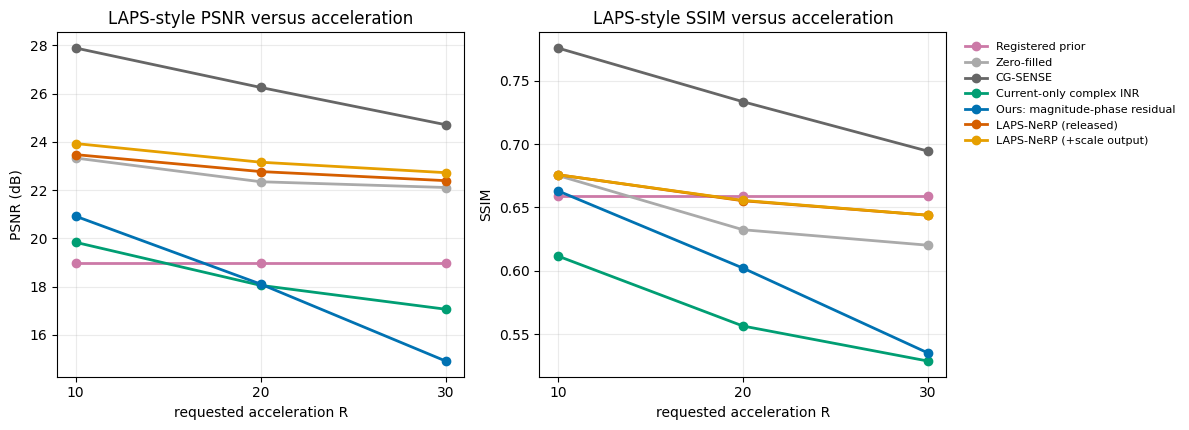

In [31]:
colors = {
    prior_method: '#CC79A7',
    primary_method: '#0072B2',
    nerp_release_method: '#D55E00',
    nerp_scaled_method: '#E69F00',
    'CG-SENSE': '#666666',
    'Zero-filled': '#AAAAAA',
    current_method: '#009E73',
    complex_method: '#56B4E9',
}

figure, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for method in present_methods:
    method_data = aggregate[aggregate['method'] == method].sort_values('requested_r')
    x = method_data['requested_r'].to_numpy(float)
    for axis, mean_column, std_column, ylabel in [
        (axes[0], 'laps_psnr_mean', 'laps_psnr_std', 'PSNR (dB)'),
        (axes[1], 'laps_ssim_mean', 'laps_ssim_std', 'SSIM'),
    ]:
        mean = method_data[mean_column].to_numpy(float)
        std = method_data[std_column].fillna(0).to_numpy(float)
        axis.plot(
            x,
            mean,
            marker='o',
            linewidth=2,
            label=method,
            color=colors.get(method),
        )
        if np.any(std > 0):
            axis.fill_between(x, mean - std, mean + std, alpha=0.14, color=colors.get(method))
        axis.set_xlabel('requested acceleration R')
        axis.set_ylabel(ylabel)
        axis.set_xticks(sorted(results['requested_r'].unique()))
        axis.grid(alpha=0.25)

axes[0].set_title('LAPS-style PSNR versus acceleration')
axes[1].set_title('LAPS-style SSIM versus acceleration')
axes[1].legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
figure.tight_layout()
plt.show()

## Qualitative reconstruction and magnitude-error maps

Each lower panel is the requested reconstruction error magnitude,

$$5\,\big|\,|\hat x|-|x_{\mathrm{ref}}|\,\big|,$$

shown on a fixed `[0, 1]` range. The factor of five follows the presentation style of the LAPS qualitative experiment; the CSV stores the unamplified MAE, RMSE, NRMSE, and maximum magnitude error.

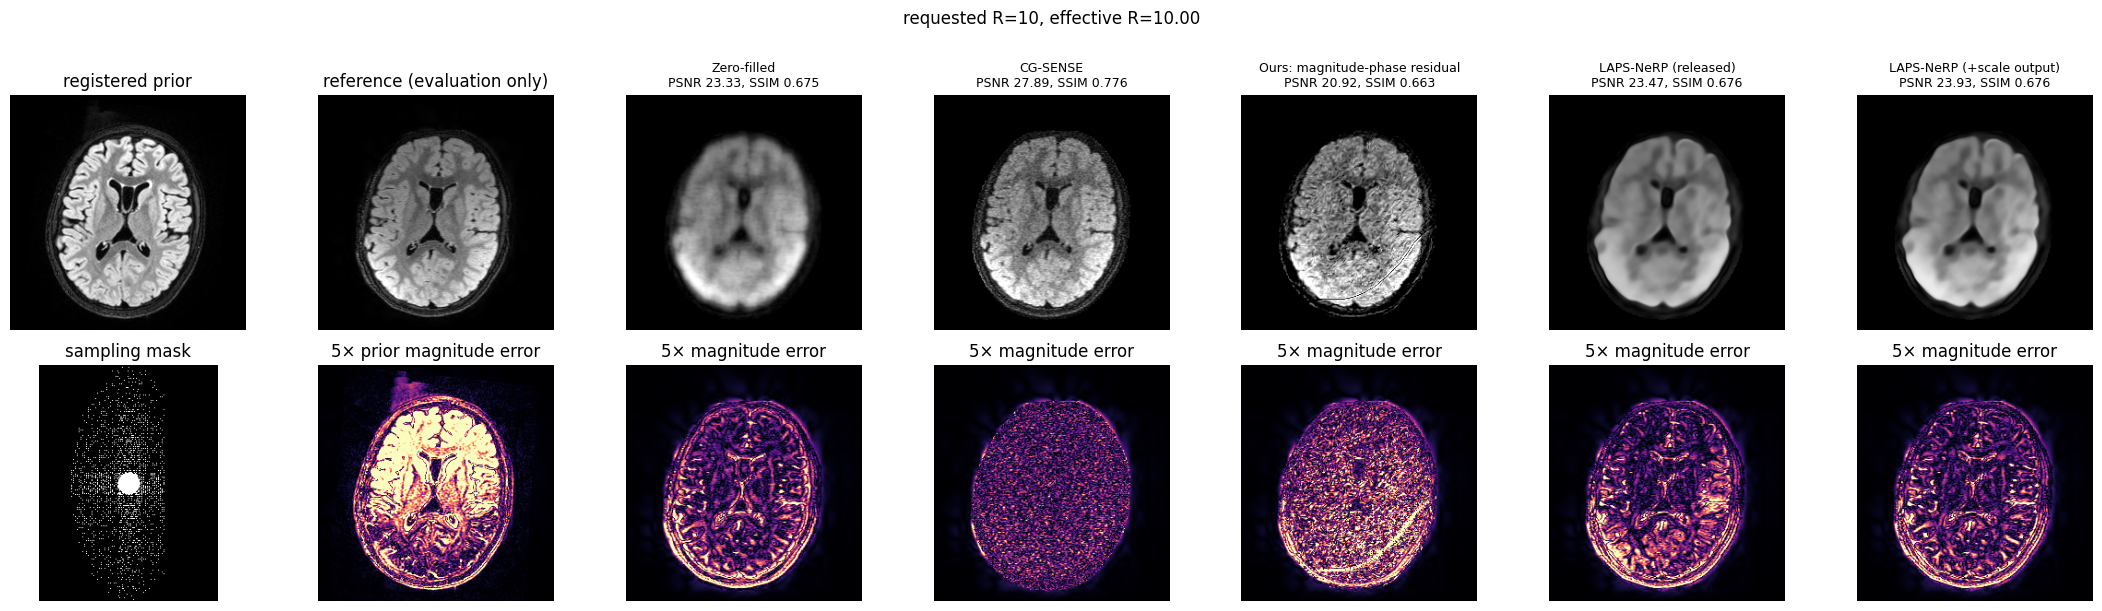

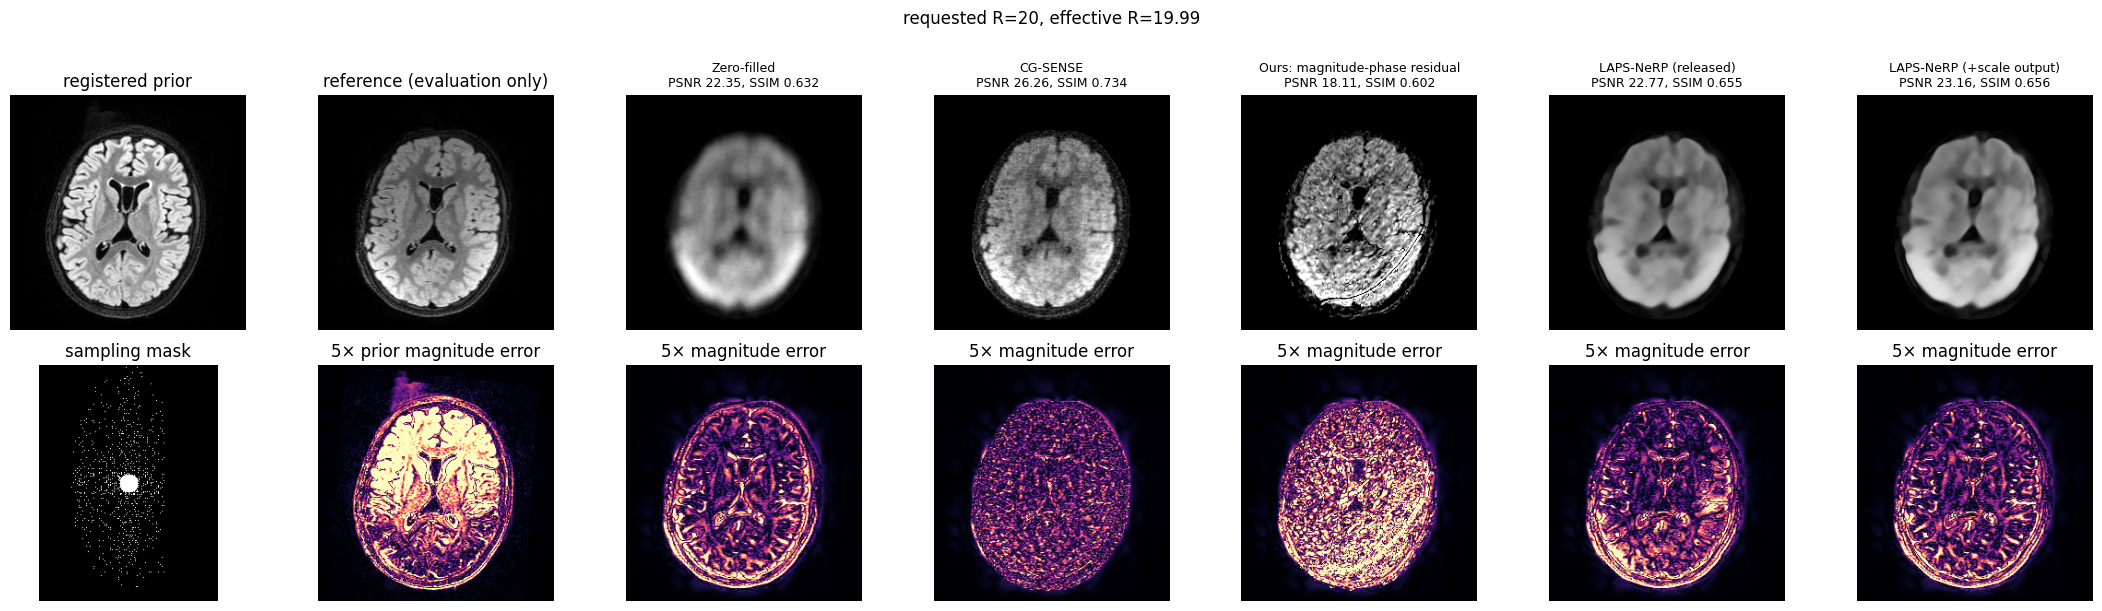

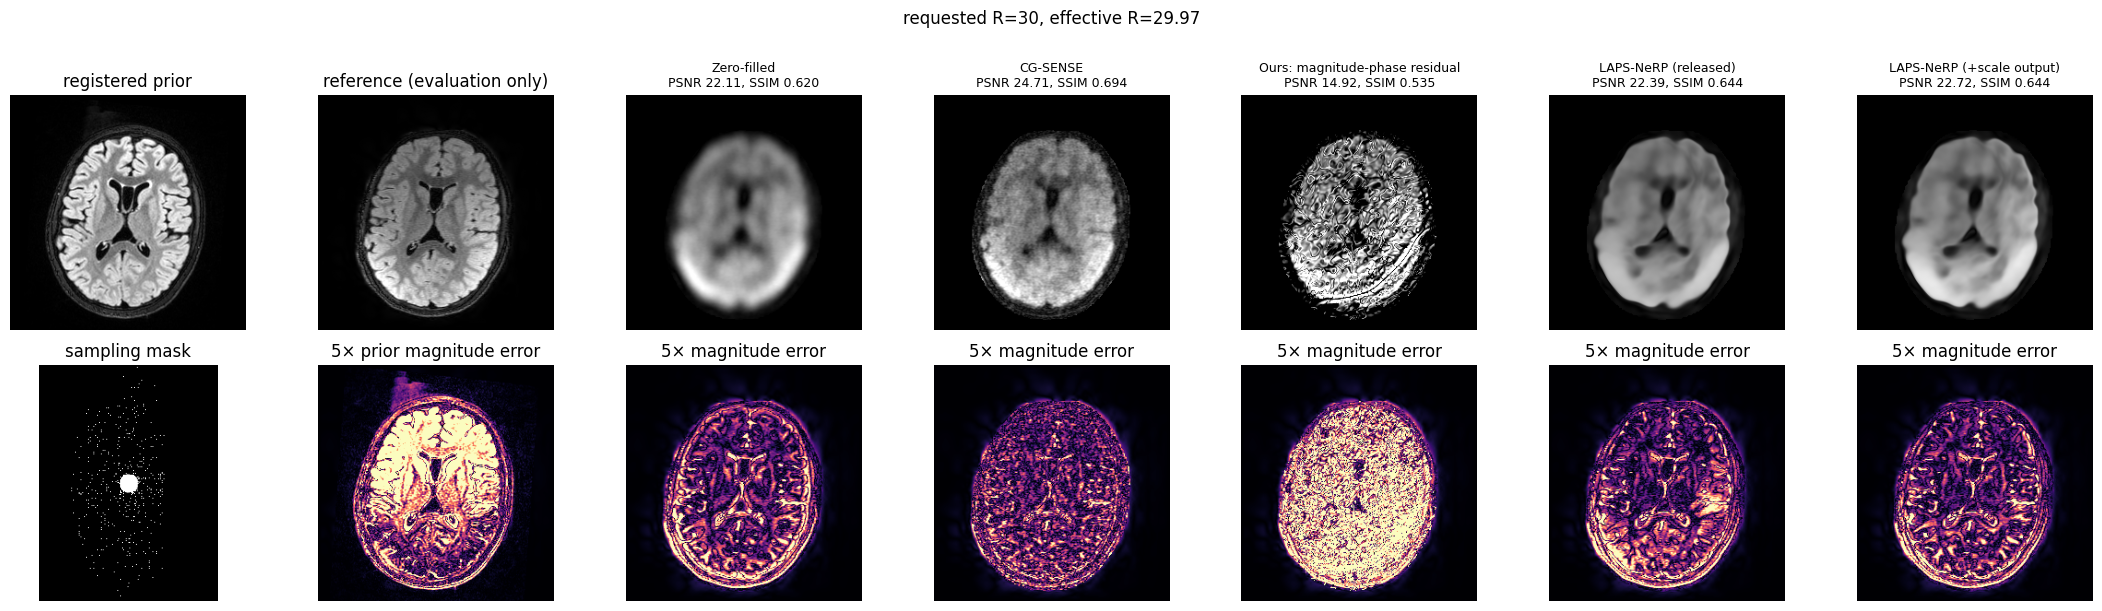

In [32]:
if not artifacts:
    print('No in-memory artifacts are available (likely every row was resumed).')
    print('Set RESUME=False for one case, or inspect the saved CSV metrics.')
else:
    qualitative_methods = [
        'Zero-filled',
        'CG-SENSE',
        primary_method,
        nerp_release_method,
    ]
    if REPORT_NERP_SCALE_OUTPUT:
        qualitative_methods.append(nerp_scaled_method)

    for requested_r in [r for r in TABLE_R if r in artifacts]:
        item = artifacts[requested_r]
        reference_magnitude = np.abs(to_numpy(item['reference']))
        vmax = float(np.quantile(reference_magnitude, 0.999))
        available = [m for m in qualitative_methods if m in item['recons']]
        figure, axes = plt.subplots(2, len(available) + 2, figsize=(3.1 * (len(available) + 2), 6.0))

        axes[0, 0].imshow(np.abs(to_numpy(item['prior'])), cmap='gray', vmin=0, vmax=vmax)
        axes[0, 0].set_title('registered prior')
        axes[1, 0].imshow(to_numpy(item['mask']), cmap='gray', vmin=0, vmax=1)
        axes[1, 0].set_title('sampling mask')

        axes[0, 1].imshow(reference_magnitude, cmap='gray', vmin=0, vmax=vmax)
        axes[0, 1].set_title('reference (evaluation only)')
        prior_error = 5.0 * np.abs(np.abs(to_numpy(item['prior'])) - reference_magnitude)
        axes[1, 1].imshow(prior_error, cmap='magma', vmin=0, vmax=1)
        axes[1, 1].set_title('5× prior magnitude error')

        for column, method in enumerate(available, start=2):
            reconstruction = item['recons'][method]
            reconstruction_magnitude = np.abs(to_numpy(reconstruction))
            error_magnitude = 5.0 * np.abs(reconstruction_magnitude - reference_magnitude)
            values = laps_metrics(reconstruction, item['reference'])
            axes[0, column].imshow(
                reconstruction_magnitude, cmap='gray', vmin=0, vmax=vmax
            )
            axes[0, column].set_title(
                f"{method}\nPSNR {values['laps_psnr']:.2f}, SSIM {values['laps_ssim']:.3f}",
                fontsize=9,
            )
            axes[1, column].imshow(error_magnitude, cmap='magma', vmin=0, vmax=1)
            axes[1, column].set_title('5× magnitude error')

        for axis in axes.flat:
            axis.axis('off')
        figure.suptitle(
            f"requested R={requested_r}, effective R={item['effective_r']:.2f}",
            y=1.01,
        )
        figure.tight_layout()
        plt.show()

## Convergence diagnostics

These curves answer a crucial question before comparing final images: did either optimizer simply stop too early? In `quick`, both methods are intentionally under-trained. In `pilot`/`paper`, LAPS-NeRP uses the release's relative-improvement early stopping and our method uses its configured fixed iteration count.

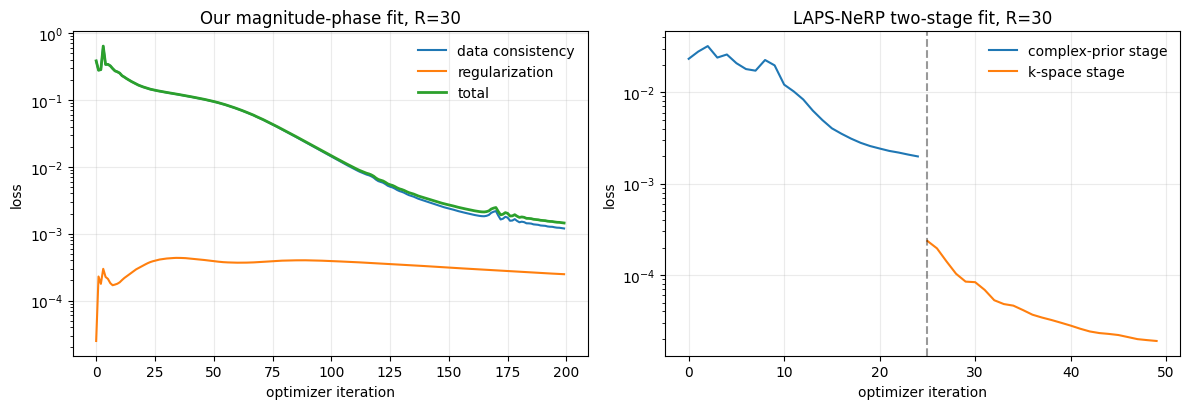

In [33]:
if artifacts:
    last_r = next(reversed(artifacts))
    histories = artifacts[last_r]['histories']
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    if primary_method in histories:
        ours_history = histories[primary_method]
        axes[0].plot(ours_history['dc'], label='data consistency')
        axes[0].plot(ours_history['reg'], label='regularization')
        axes[0].plot(ours_history['loss'], label='total', linewidth=2)
        axes[0].set_title(f'Our magnitude-phase fit, R={last_r}')
        axes[0].set_yscale('log')
        axes[0].legend(frameon=False)
    else:
        axes[0].text(0.5, 0.5, 'Our history not in memory', ha='center')

    if nerp_release_method in histories:
        nerp_history = histories[nerp_release_method]
        axes[1].plot(nerp_history['prior']['loss'], label='complex-prior stage')
        offset = len(nerp_history['prior']['loss'])
        axes[1].plot(
            np.arange(len(nerp_history['kspace']['loss'])) + offset,
            nerp_history['kspace']['loss'],
            label='k-space stage',
        )
        axes[1].axvline(offset, color='black', linestyle='--', alpha=0.4)
        axes[1].set_title(f'LAPS-NeRP two-stage fit, R={last_r}')
        axes[1].set_yscale('log')
        axes[1].legend(frameon=False)
    else:
        axes[1].text(0.5, 0.5, 'NeRP history not in memory', ha='center')

    for axis in axes:
        axis.set_xlabel('optimizer iteration')
        axis.set_ylabel('loss')
        axis.grid(alpha=0.25)
    figure.tight_layout()
    plt.show()

## How to interpret the comparison

- Compare **our primary method** with **LAPS-NeRP (released)** first; that is the direct implementation comparison.
- Treat **LAPS-NeRP (+scale output)** as a code-path diagnostic. A large released/scaled gap means the final-output scale omission matters for this case.
- Use `laps_psnr` and `laps_ssim` when comparing with Table 2a (1D) or Table 2b (2D). Use the project-native metrics and the magnitude-error columns when judging absolute amplitude fidelity.
- If both prior-based methods improve over `Current-only complex INR` (when enabled), the patient prior is contributing beyond coordinate-network bias.
- Inspect `change_cosine`, `change_gain`, and `mi_prior_delta` alongside global PSNR/SSIM. A method can obtain a good global score by copying unchanged anatomy while missing a localized longitudinal change.
- Do not compare `quick` values with the paper. A defensible result needs the exact optimizer settings, the completed 225-slice 1D or 150-slice 2D cohort, and preferably ACS-derived ESPIRiT sensitivity maps.

The published Table 2a/2b LAPS-NeRP values are included only as full-run validation targets. Differences can come from cohort completeness, sensitivity-map estimation, random masks, per-scan normalization, optimizer convergence, or the release's final scale behavior.